Import dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [3]:
import os

folder_path = '/content/drive/MyDrive/Colab Notebooks'
os.listdir(folder_path)

['numpy4.ipynb',
 'preprocessing.ipynb',
 'titanic_dataset.ipynb',
 'handle_missing_values.ipynb',
 'feature_scaling.ipynb',
 'feature_engineering.ipynb',
 'creditcard.csv',
 'final_xgb_model.joblib',
 'creditcard_preprocessed.csv',
 'credit_fraud _detectionipynb.ipynb',
 'credit_card_fraud_detection.ipynb',
 'housing_prices.ipynb',
 'Untitled0.ipynb',
 'Untitled1.ipynb']

Read the dataset

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())

Shape of dataset: (284807, 31)

Columns:
 Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

First 5 rows:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.

Find missing value or see if there are any missing values

In [7]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


class 0 = normal transaction
class 1 = fraud transaction

In [8]:

print("\nClass distribution:\n", df['Class'].value_counts())


Class distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


handling outlier

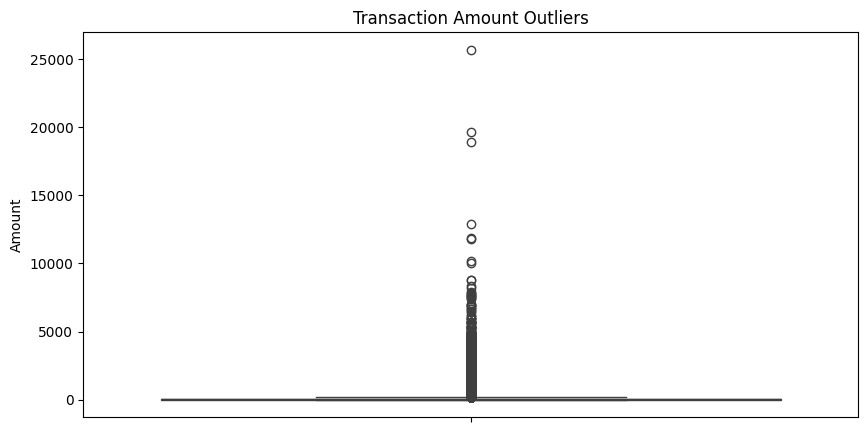

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot to check outliers
plt.figure(figsize=(10,5))
sns.boxplot(df['Amount'])
plt.title('Transaction Amount Outliers')
plt.show()


using log transformation as data is heavily skewed (positive skewed) instead of going with IQR that is better when we have few outliers

In [10]:
import numpy as np
df['Amount_log'] = np.log1p(df['Amount'])


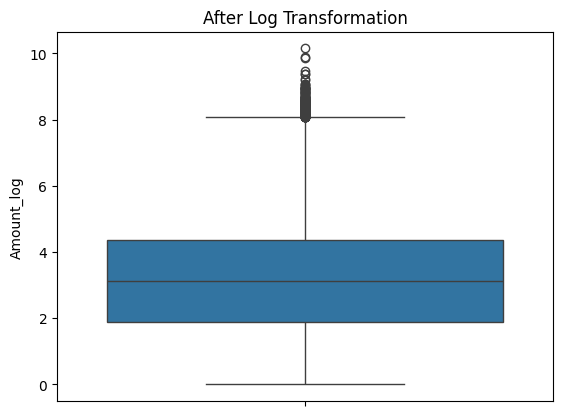

In [11]:
sns.boxplot(df['Amount_log'])
plt.title('After Log Transformation')
plt.show()


blue box where the middle 50% value lies, 3.2 approx mdeian value line inside blue box

scaling using standard scaler

In [12]:
from sklearn.preprocessing import StandardScaler


In [13]:
scaler = StandardScaler()

# Fit only on Amount_log (after log transformation)
df['Amount_scaled'] = scaler.fit_transform(df[['Amount_log']])


In [14]:
df = df.drop(['Amount', 'Amount_log'], axis=1)


In [16]:
print(df['Amount_scaled'].describe())


count    2.848070e+05
mean     9.420447e-17
std      1.000002e+00
min     -1.902754e+00
25%     -7.636627e-01
50%     -1.007690e-02
75%      7.283598e-01
max      4.226464e+00
Name: Amount_scaled, dtype: float64


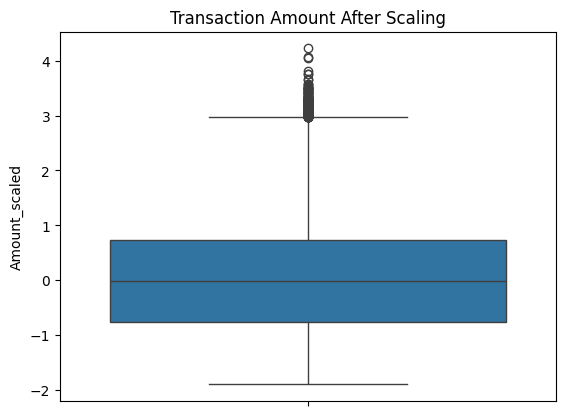

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Amount_scaled'])
plt.title('Transaction Amount After Scaling')
plt.show()


separate feature and target

In [17]:
X = df.drop(['Class'], axis=1)
y = df['Class']


train-test-split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


SMOTE (Synthetic Minority Oversampling Technique) → creates synthetic fraud examples as the data is highly imbalance 99% transaction are true and only 1% are fraud

In [19]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)


In [20]:
y_train_res.value_counts()


,count
Class,
0,227451
1,227451


Training set → balanced using SMOTE

Test set → left untouched (original fraud ratio)

Import and Train Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train_res, y_train_res)



LogisticRegression(max_iter=5000, random_state=42)

In [24]:
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]


In [25]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))


Confusion Matrix:
[[56267   597]
 [    9    89]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.91      0.23        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.61     56962
weighted avg       1.00      0.99      0.99     56962


ROC-AUC Score: 0.9753790461738999


Precision recall curve  why? when data is highly imabalance roc can still be great

<Figure size 600x400 with 0 Axes>

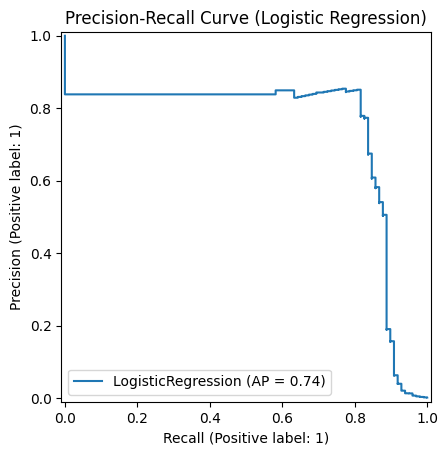

In [26]:
from sklearn.metrics import PrecisionRecallDisplay

# --- Precision-Recall Curve Visualization ---
plt.figure(figsize=(6, 4))
PrecisionRecallDisplay.from_estimator(lr, X_test, y_test)
plt.title("Precision-Recall Curve (Logistic Regression)")
plt.show()


Train and compare 3–4 algorithms on the same preprocessed (SMOTE) data

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train and evaluate each
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.91      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.95      0.62     56962
weighted avg       1.00      0.99      0.99     56962


Model: Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.40      0.80      0.53        98

    accuracy                           1.00     56962
   macro avg       0.70      0.90      0.77     56962
weighted avg       1.00      1.00      1.00     56962


Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.92     56962
we

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [03:29:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.89      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results)
print(df_results)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.990099   0.138199  0.908163  0.239892  0.974558
1        Decision Tree  0.997595   0.400000  0.795918  0.532423  0.896930
2        Random Forest  0.999421   0.835052  0.826531  0.830769  0.968864
3              XGBoost  0.999368   0.787037  0.867347  0.825243  0.984759


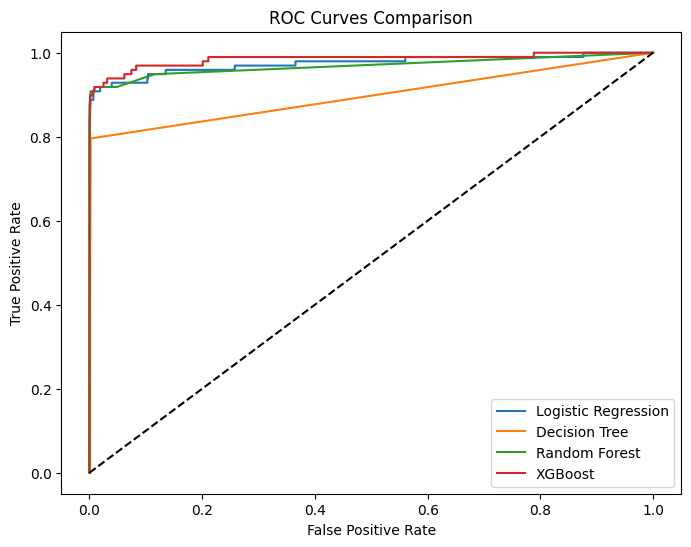

In [29]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.show()


In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# Initialize the model
xgb_model = XGBClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=1  # Because you used SMOTE, data is balanced
)

# Train the model
xgb_model.fit(X_train_res, y_train_res)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


Accuracy: 0.9988939995084443
ROC-AUC: 0.9827691276285414

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.88      0.73        98

    accuracy                           1.00     56962
   macro avg       0.81      0.94      0.87     56962
weighted avg       1.00      1.00      1.00     56962



Step 9: Feature Importance & Interpretability

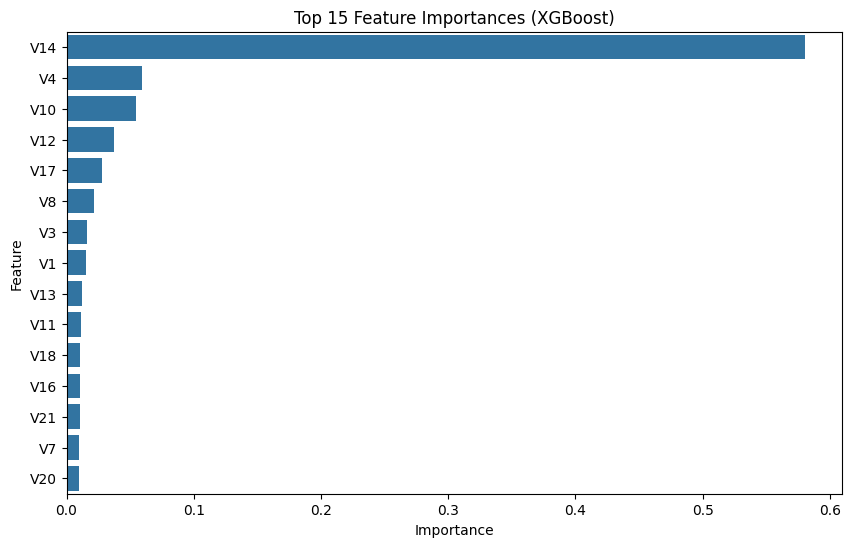

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get feature importances
importances = xgb_model.feature_importances_
features = X_train.columns

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_importance.head(15))
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()


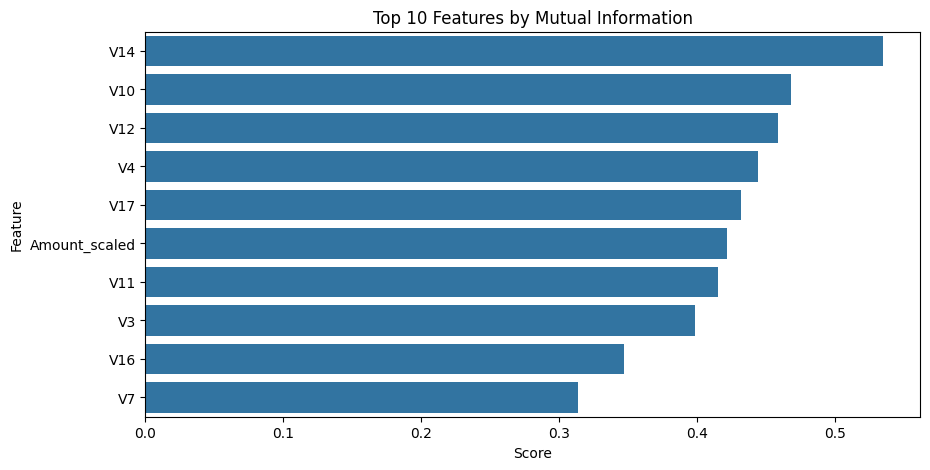

In [32]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Apply SelectKBest
selector = SelectKBest(score_func=mutual_info_classif, k=10)
X_new = selector.fit_transform(X_train_res, y_train_res)

# Get the scores
scores = selector.scores_
feature_scores = pd.DataFrame({'Feature': X_train_res.columns, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

# Visualize top 10 features
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(10))
plt.title('Top 10 Features by Mutual Information')
plt.show()

# Keep only the top features
selected_features = feature_scores.head(10)['Feature'].tolist()
X_train_selected = X_train_res[selected_features]
X_test_selected = X_test[selected_features]


Final Metrics: {'Accuracy': np.float64(0.9989), 'Precision': np.float64(0.6277), 'Recall': np.float64(0.8776), 'F1': np.float64(0.7319), 'ROC-AUC': np.float64(0.9828), 'PR-AUC': np.float64(0.8753)}


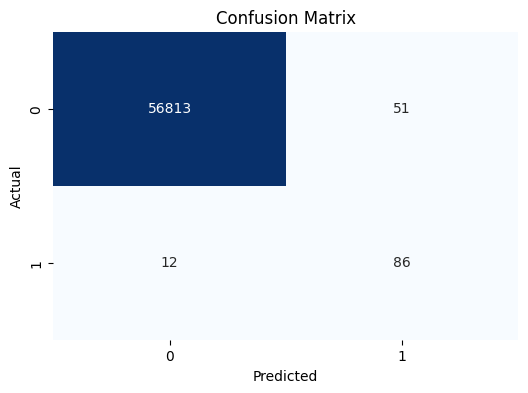

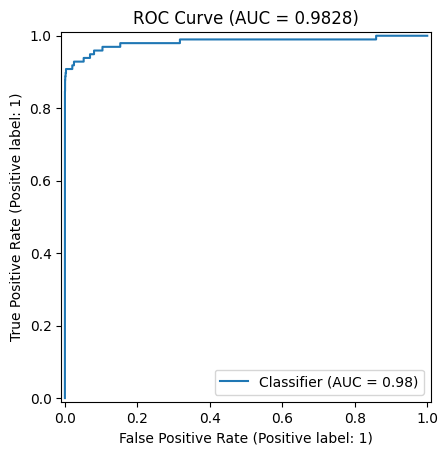

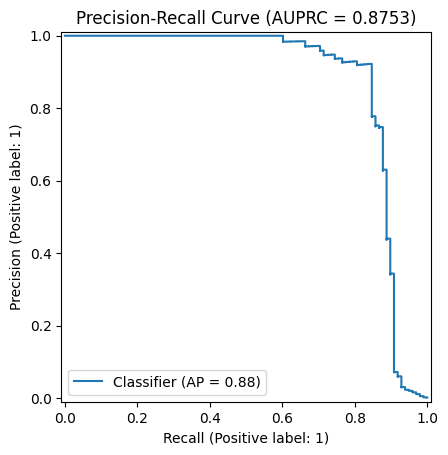

In [33]:
# 1. Final evaluation & table
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# choose model and probabilities (replace xgb_model with your chosen model variable)
model = xgb_model  # or rf for RandomForest
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

# metrics
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)
prec, rec, thr = precision_recall_curve(y_test, y_proba)
pr_auc = auc(rec, prec)

# print summary table
results_summary = {
    'Accuracy': np.round((cm[0,0]+cm[1,1]) / cm.sum(), 4),
    'Precision': np.round(report['1']['precision'], 4),
    'Recall': np.round(report['1']['recall'], 4),
    'F1': np.round(report['1']['f1-score'], 4),
    'ROC-AUC': np.round(roc_auc, 4),
    'PR-AUC': np.round(pr_auc, 4)
}
print("Final Metrics:", results_summary)

# Confusion matrix plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
plt.show()

# Precision-Recall curve
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f'Precision-Recall Curve (AUPRC = {pr_auc:.4f})')
plt.show()


In [34]:
# Save model
import joblib
joblib.dump(model, '/content/drive/MyDrive/Colab Notebooks/final_xgb_model.joblib')  # change path as needed

# Export cleaned, preprocessed dataset (X and y combined)
df_clean = X.copy()
df_clean['Class'] = y
df_clean.to_csv('/content/drive/MyDrive/Colab Notebooks/creditcard_preprocessed.csv', index=False)
print("Saved model and cleaned CSV to Drive.")


KeyboardInterrupt: 

In [35]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

In [36]:
shap_values.shape

(56962, 30)

In [37]:
row_idx = 0

shap_row = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_value': shap_values[row_idx]
}).sort_values(by='SHAP_value', key=abs, ascending=False)

print(shap_row.head(10))

   Feature  SHAP_value
4       V4   -4.709258
14     V14   -2.003313
11     V11   -0.812526
10     V10   -0.644936
2       V2   -0.634814
6       V6   -0.436767
8       V8    0.384760
23     V23   -0.312747
18     V18   -0.291904
17     V17    0.257469


In [38]:
print("Predicted probability:", y_pred_proba_xgb[row_idx])
print("Predicted label:", y_pred_xgb[row_idx])
print("Actual label:", y_test.iloc[row_idx])
print("Base value:", explainer.expected_value)

Predicted probability: 5.3430813e-05
Predicted label: 0
Actual label: 0
Base value: -0.06505601


In [39]:
fraud_indices = np.where(y_pred_xgb == 1)[0]
print("Number of predicted fraud cases:", len(fraud_indices))
print("First few indices:", fraud_indices[:5])

Number of predicted fraud cases: 137
First few indices: [ 165  586  840 1146 1390]


In [40]:
row_idx = 165

print("Predicted probability:", y_pred_proba_xgb[row_idx])
print("Predicted label:", y_pred_xgb[row_idx])
print("Actual label:", y_test.iloc[row_idx])
print("Base value:", explainer.expected_value)

shap_row = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP_value': shap_values[row_idx]
}).sort_values(by='SHAP_value', key=abs, ascending=False)

print(shap_row.head(10))

Predicted probability: 0.9921003
Predicted label: 1
Actual label: 0
Base value: -0.06505601
   Feature  SHAP_value
14     V14    2.136811
17     V17    1.924984
10     V10    1.547372
8       V8   -1.201995
7       V7    1.071956
12     V12    0.961507
3       V3    0.837366
2       V2   -0.734529
11     V11    0.708815
4       V4   -0.667323


In [41]:
def get_top_shap_features(row_idx, n=5):
    shap_row = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_value': shap_values[row_idx]
    }).sort_values(by='SHAP_value', key=abs, ascending=False)
    return shap_row.head(n)

In [42]:
get_top_shap_features(165)

,Feature,SHAP_value
14,V14,2.136811
17,V17,1.924984
10,V10,1.547372
8,V8,-1.201995
7,V7,1.071956


stage 1

In [43]:
def get_top_shap_features(row_idx, n=5):
    shap_row = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_value': shap_values[row_idx],
        'Feature_value': X_test.iloc[row_idx].values
    }).sort_values(by='SHAP_value', key=abs, ascending=False)
    return shap_row.head(n)

In [44]:
get_top_shap_features(165)

,Feature,SHAP_value,Feature_value
14,V14,2.136811,-2.426168
17,V17,1.924984,-6.199008
10,V10,1.547372,-3.345061
8,V8,-1.201995,1.173920
7,V7,1.071956,-1.954054


converting data frame to list or dic

In [45]:
def get_top_shap_features(row_idx, n=5):
    shap_row = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_value': shap_values[row_idx],
        'Feature_value': X_test.iloc[row_idx].values
    }).sort_values(by='SHAP_value', key=abs, ascending=False).head(n)

    return shap_row.to_dict('records')

In [46]:
get_top_shap_features(165)

[{'Feature': 'V14',
  'SHAP_value': 2.1368112564086914,
  'Feature_value': -2.42616754529086},
 {'Feature': 'V17',
  'SHAP_value': 1.9249839782714844,
  'Feature_value': -6.19900773693385},
 {'Feature': 'V10',
  'SHAP_value': 1.5473716259002686,
  'Feature_value': -3.34506130667145},
 {'Feature': 'V8',
  'SHAP_value': -1.2019950151443481,
  'Feature_value': 1.17391997369635},
 {'Feature': 'V7',
  'SHAP_value': 1.0719561576843262,
  'Feature_value': -1.95405395436729}]

rounding of decimal places and Decide whether to include the case's overall predicted probability + base value in this output too

In [49]:
def get_case_explanation_input(row_idx, n=5):
    shap_row = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP_value': shap_values[row_idx].astype(float),
        'Feature_value': X_test.iloc[row_idx].values.astype(float)
    }).sort_values(by='SHAP_value', key=abs, ascending=False).head(n)

    shap_row = shap_row.round(3)

    return {
        'predicted_probability': round(float(y_pred_proba_xgb[row_idx]), 4),
        'predicted_label': int(y_pred_xgb[row_idx]),
        'top_features': shap_row.to_dict('records')
    }

In [50]:
get_case_explanation_input(165)

{'predicted_probability': 0.9921,
 'predicted_label': 1,
 'top_features': [{'Feature': 'V14',
   'SHAP_value': 2.137,
   'Feature_value': -2.426},
  {'Feature': 'V17', 'SHAP_value': 1.925, 'Feature_value': -6.199},
  {'Feature': 'V10', 'SHAP_value': 1.547, 'Feature_value': -3.345},
  {'Feature': 'V8', 'SHAP_value': -1.202, 'Feature_value': 1.174},
  {'Feature': 'V7', 'SHAP_value': 1.072, 'Feature_value': -1.954}]}

In [53]:
!pip install -q google-generativeai
import google.generativeai as genai

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [54]:
from google.colab import userdata

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))
model = genai.GenerativeModel('gemini-1.5-flash')


In [57]:
model = genai.GenerativeModel('gemini-3.6-flash')

response = model.generate_content(prompt)
print(response.text)

This transaction has been flagged with an extremely high fraud probability of **99.2%**. The primary drivers behind this risk score are severe abnormal patterns in key transaction features (V14, V17, and V10), which closely match known fraudulent behavior profiles. While a single minor indicator (V8) slightly pushed toward legitimacy, it is heavily outweighed by these strong risk signals. We recommend prioritizing this account for immediate review or temporary block.


In [58]:
def generate_case_explanation(row_idx):
    case_data = get_case_explanation_input(row_idx)

    prompt = f"""
You are a fraud analyst assistant. Explain this flagged transaction in plain English for a bank analyst reviewing it.

Predicted fraud probability: {case_data['predicted_probability']}
Predicted label: {'Fraud' if case_data['predicted_label'] == 1 else 'Not Fraud'}

Top contributing factors (feature, SHAP impact, actual value):
{case_data['top_features']}

Write a short 3-4 sentence explanation a non-technical analyst can understand.
"""

    response = model.generate_content(prompt)
    return response.text

In [59]:
print(generate_case_explanation(165))

This transaction has been flagged with an extremely high fraud risk of **99.2%**. The primary drivers of this alert are severe negative deviations in transaction pattern indicators **V14**, **V17**, and **V10**, which strongly align with known fraudulent activity. While feature **V8** provided minor evidence typical of a legitimate transaction, its impact was heavily outweighed by the combined risk signals from **V14**, **V17**, **V10**, and **V7**. Immediate manual review and customer verification are strongly recommended before processing.


stage 3

In [60]:
def analyze_transaction(row_idx):
    prediction = int(y_pred_xgb[row_idx])
    probability = float(y_pred_proba_xgb[row_idx])

    if prediction == 0:
        return {
            'row_idx': row_idx,
            'flagged': False,
            'probability': round(probability, 4),
            'explanation': None
        }

    explanation = generate_case_explanation(row_idx)

    return {
        'row_idx': row_idx,
        'flagged': True,
        'probability': round(probability, 4),
        'explanation': explanation
    }

In [64]:
analyze_transaction(165)


{'row_idx': 165,
 'flagged': True,
 'probability': 0.9921,
 'explanation': 'This transaction has been flagged as extremely high risk with a **99.2% fraud probability**. The primary drivers for this alert are severe anomalies in transaction patterns (specifically features V14, V17, and V10), whose negative values strongly align with historical fraud behaviors. Although a positive V8 value slightly offset the risk, the overall transaction signature overwhelmingly points to fraudulent activity. Immediate review and cardholder verification are recommended before taking further action.'}

In [63]:
analyze_transaction(0)

{'row_idx': 0, 'flagged': False, 'probability': 0.0001, 'explanation': None}

In [66]:
import time
import pandas as pd


def run_batch_analysis(indices, delay=4):
    results = []
    for idx in indices:
        for attempt in range(3):
            try:
                results.append(analyze_transaction(idx))
                break
            except Exception as e:
                print(f"Row {idx} failed (attempt {attempt+1}): {e}")
                time.sleep(15)
        time.sleep(delay)
    return pd.DataFrame(results)

batch_results = run_batch_analysis(fraud_indices[:25])
batch_results.to_csv('fraud_case_explanations.csv', index=False)
batch_results.head()

Row 165 failed (attempt 1): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 57.017693554s.


Row 165 failed (attempt 2): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 41.380151938s.


Row 165 failed (attempt 3): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 25.652106793s.


Row 586 failed (attempt 1): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 6.089506015s.


Row 586 failed (attempt 2): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 50.601870106s.


...

Row 5077 failed (attempt 3): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 9.919627524s.


Row 5258 failed (attempt 1): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 50.366219093s.


Row 5258 failed (attempt 2): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 34.794811395s.


Row 5258 failed (attempt 3): 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash
Please retry in 18.761078691s.


KeyboardInterrupt: 

In [67]:
model = genai.GenerativeModel('gemini-3.1-flash-lite')
batch_results = run_batch_analysis(fraud_indices[:8], delay=6)
batch_results.to_csv('fraud_case_explanations.csv', index=False)
batch_results.head()

,row_idx,flagged,probability,explanation
0,165,True,0.9921,This transaction has been flagged with a 99% p...
1,586,True,0.9215,This transaction has been flagged as high-risk...
2,840,True,0.9996,This transaction has been flagged with an extr...
3,1146,True,1.0000,This transaction has been flagged with a 100% ...
4,1390,True,0.7481,This transaction has been flagged as high-risk...
